In [1]:
# ==============================
# PHASE 1 - IMPORT LIBRARIES
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

print("All Libraries Imported Successfully")

All Libraries Imported Successfully


In [2]:
# ============================================
# PHASE 2 - CREATE WEB TRAFFIC DATASET
# ============================================

import pandas as pd
import numpy as np

np.random.seed(42)

pages = ["Home","Products","About","Pricing","Blog","Contact"]
devices = ["Desktop","Mobile","Tablet"]
sources = ["Google","Direct","Facebook","Instagram","LinkedIn","YouTube"]

rows = 5000

df = pd.DataFrame({
    "User_ID": np.arange(1, rows+1),
    "Page": np.random.choice(pages, rows),
    "Device": np.random.choice(devices, rows),
    "Traffic_Source": np.random.choice(sources, rows),
    "Session_Duration": np.random.randint(10,600,rows),
    "Pages_Visited": np.random.randint(1,15,rows),
    "Bounce": np.random.choice([0,1], rows, p=[0.65,0.35])
})

print("Dataset Created Successfully")
print(df.head())

# Save Dataset
df.to_csv("web_traffic.csv", index=False)
print("\nDataset saved as web_traffic.csv")

Dataset Created Successfully
   User_ID     Page   Device Traffic_Source  Session_Duration  Pages_Visited  \
0        1  Pricing   Tablet         Direct               317              3   
1        2     Blog  Desktop       Facebook               502              3   
2        3    About   Tablet        YouTube               347             12   
3        4     Blog  Desktop       LinkedIn                75              5   
4        5     Blog  Desktop        YouTube               431              7   

   Bounce  
0       0  
1       1  
2       0  
3       1  
4       0  

Dataset saved as web_traffic.csv


In [3]:
# ============================================
# PHASE 3 - DATA EXPLORATION
# ============================================

print("First 10 Records")
print(df.head(10))


First 10 Records
   User_ID      Page   Device Traffic_Source  Session_Duration  Pages_Visited  \
0        1   Pricing   Tablet         Direct               317              3   
1        2      Blog  Desktop       Facebook               502              3   
2        3     About   Tablet        YouTube               347             12   
3        4      Blog  Desktop       LinkedIn                75              5   
4        5      Blog  Desktop        YouTube               431              7   
5        6  Products  Desktop        YouTube               549             14   
6        7     About   Mobile       Facebook               502              5   
7        8     About   Mobile         Direct               326             11   
8        9     About  Desktop         Google                84              8   
9       10      Blog  Desktop      Instagram                68              5   

   Bounce  
0       0  
1       1  
2       0  
3       1  
4       0  
5       1  
6      

In [4]:
print("\nLast 10 Records")
print(df.tail(10))


Last 10 Records
      User_ID      Page   Device Traffic_Source  Session_Duration  \
4990     4991     About  Desktop      Instagram               213   
4991     4992      Blog  Desktop         Direct               132   
4992     4993   Contact   Mobile      Instagram               579   
4993     4994   Contact  Desktop      Instagram               456   
4994     4995      Home   Mobile       Facebook               500   
4995     4996  Products   Mobile         Direct               442   
4996     4997     About   Mobile         Direct               137   
4997     4998  Products  Desktop       LinkedIn               557   
4998     4999   Contact  Desktop       LinkedIn                56   
4999     5000   Contact  Desktop         Google               514   

      Pages_Visited  Bounce  
4990              2       1  
4991              2       0  
4992             10       0  
4993              1       0  
4994             14       1  
4995             13       0  
4996         

In [10]:
print("\nShape")
print(df.shape)


Shape
(5000, 7)


In [12]:
print("\nColumns")
print(df.columns)
print("\nData Types")
print(df.dtypes)


Columns
Index(['User_ID', 'Page', 'Device', 'Traffic_Source', 'Session_Duration',
       'Pages_Visited', 'Bounce'],
      dtype='object')

Data Types
User_ID              int64
Page                object
Device              object
Traffic_Source      object
Session_Duration     int32
Pages_Visited        int32
Bounce               int64
dtype: object


In [13]:
print("\nMissing Values")
print(df.isnull().sum())


Missing Values
User_ID             0
Page                0
Device              0
Traffic_Source      0
Session_Duration    0
Pages_Visited       0
Bounce              0
dtype: int64


In [14]:
print("\nDuplicate Rows")
print(df.duplicated().sum())


Duplicate Rows
0


In [15]:
print("\nStatistical Summary")
print(df.describe())


Statistical Summary
           User_ID  Session_Duration  Pages_Visited       Bounce
count  5000.000000       5000.000000    5000.000000  5000.000000
mean   2500.500000        302.719000       7.457600     0.350400
std    1443.520003        170.659234       4.025201     0.477143
min       1.000000         10.000000       1.000000     0.000000
25%    1250.750000        156.000000       4.000000     0.000000
50%    2500.500000        299.000000       7.000000     0.000000
75%    3750.250000        450.000000      11.000000     1.000000
max    5000.000000        599.000000      14.000000     1.000000


In [17]:
print("\nCategorical Summary")
print(df.describe(include='object'))


Categorical Summary
        Page  Device Traffic_Source
count   5000    5000           5000
unique     6       3              6
top     Home  Mobile       LinkedIn
freq     870    1703            878


In [18]:
# ============================================
# PHASE 4 - DATA VISUALIZATION
# ============================================

import matplotlib.pyplot as plt

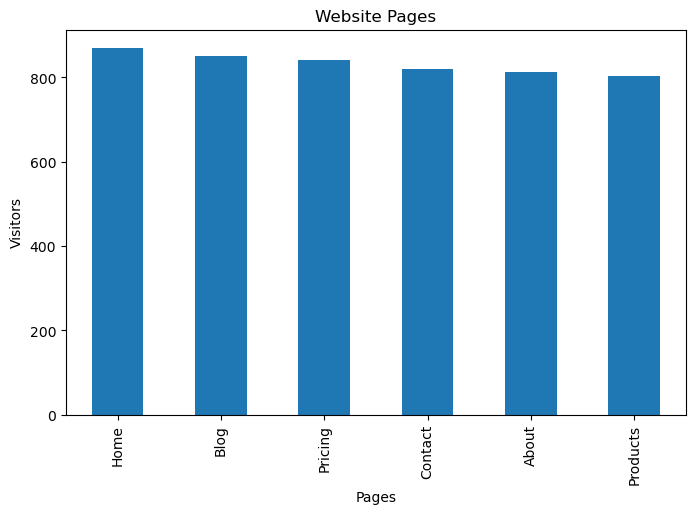

In [19]:
plt.figure(figsize=(8,5))
df["Page"].value_counts().plot(kind="bar")
plt.title("Website Pages")
plt.xlabel("Pages")
plt.ylabel("Visitors")
plt.show()

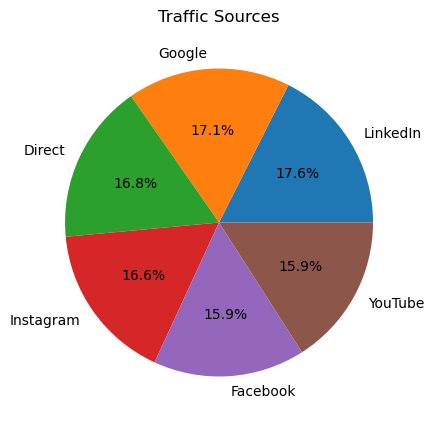

In [20]:
plt.figure(figsize=(8,5))
df["Traffic_Source"].value_counts().plot(kind="pie",autopct="%1.1f%%")
plt.ylabel("")
plt.title("Traffic Sources")
plt.show()


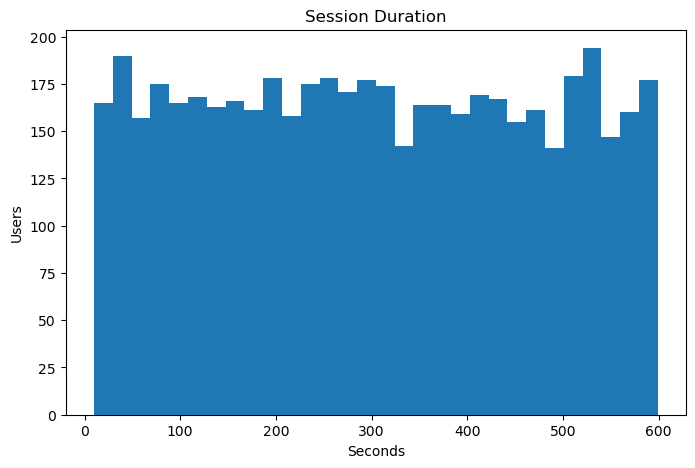

In [21]:
plt.figure(figsize=(8,5))
plt.hist(df["Session_Duration"],bins=30)
plt.title("Session Duration")
plt.xlabel("Seconds")
plt.ylabel("Users")
plt.show()

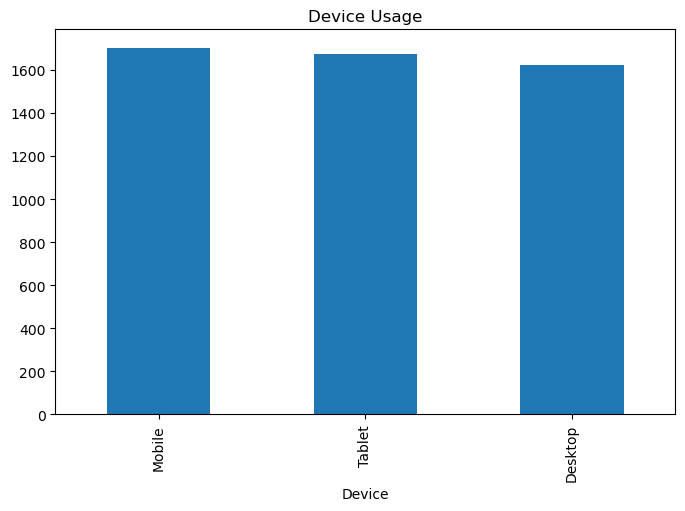

In [22]:
plt.figure(figsize=(8,5))
df["Device"].value_counts().plot(kind="bar")
plt.title("Device Usage")
plt.show()

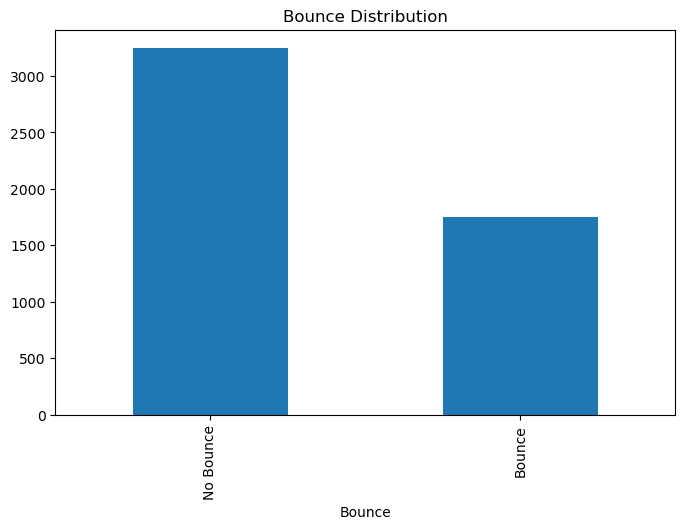

In [23]:
plt.figure(figsize=(8,5))
df["Bounce"].value_counts().plot(kind="bar")
plt.title("Bounce Distribution")
plt.xticks([0,1],["No Bounce","Bounce"])
plt.show()

In [24]:
# ============================================
# PHASE 5 - FEATURE ENGINEERING
# ============================================

from sklearn.preprocessing import LabelEncoder

encoder=LabelEncoder()

df["Page"]=encoder.fit_transform(df["Page"])
df["Device"]=encoder.fit_transform(df["Device"])
df["Traffic_Source"]=encoder.fit_transform(df["Traffic_Source"])

print(df.head())

   User_ID  Page  Device  Traffic_Source  Session_Duration  Pages_Visited  \
0        1     4       2               0               317              3   
1        2     1       0               1               502              3   
2        3     0       2               5               347             12   
3        4     1       0               4                75              5   
4        5     1       0               5               431              7   

   Bounce  
0       0  
1       1  
2       0  
3       1  
4       0  


In [25]:
# ============================================
# PHASE 6 - MACHINE LEARNING
# ============================================

from sklearn.model_selection import train_test_split

In [26]:
X=df.drop("Bounce",axis=1)
y=df["Bounce"]

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
print("Training Shape :",X_train.shape)
print("Testing Shape :",X_test.shape)

Training Shape : (4000, 6)
Testing Shape : (1000, 6)


In [28]:
# ============================================
# PHASE 7 - RANDOM FOREST MODEL
# ============================================


In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model=RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train,y_train)

y_pred=model.predict(X_test)

accuracy=accuracy_score(y_test,y_pred)

print("Accuracy :",accuracy)

Accuracy : 0.626


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))